# Taller de Inteligencia Artificial
## Predicción del Índice de Calidad del Aire (AQI) mediante Regresión Lineal

En este taller se analiza un conjunto de datos de monitoreo de **ozono (O₃)** registrado durante el año 2023 en la estación "Connecticut Hill", ubicada en el condado de Tompkins, Nueva York (EE.UU.).

El dataset contiene 355 observaciones diarias con variables como la concentración máxima de ozono en 8 horas, el índice AQI, el conteo de observaciones diarias y el porcentaje de completitud, entre otras.

Se realizará:
- Exploración y limpieza de datos
- Ingeniería de características (extracción de variables temporales)
- Análisis de correlación y visualizaciones
- Modelo de Regresión Lineal para predecir el AQI diario
- Modelo de Árbol de Decisión como comparación
- Evaluación y análisis de residuos

## 1. Importamos los paquetes

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Configuración visual
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

## 2. Cargamos el conjunto de datos

In [ ]:
df = pd.read_csv('1ozono2023.csv')
df.head(10)

,Date,Source,Site ID,POC,Daily Max 8-hour Ozone Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2023,AQS,361099991,1,0.030,ppm,28,Connecticut Hill,17,100.0,...,Ozone,47,27060,"Ithaca, NY",36,New York,109,Tompkins,42.4006,-76.6538
1,01/02/2023,AQS,361099991,1,0.027,ppm,25,Connecticut Hill,17,100.0,...,Ozone,47,27060,"Ithaca, NY",36,New York,109,Tompkins,42.4006,-76.6538
2,01/03/2023,AQS,361099991,1,0.023,ppm,21,Connecticut Hill,17,100.0,...,Ozone,47,27060,"Ithaca, NY",36,New York,109,Tompkins,42.4006,-76.6538
3,01/04/2023,AQS,361099991,1,0.027,ppm,25,Connecticut Hill,17,100.0,...,Ozone,47,27060,"Ithaca, NY",36,New York,109,Tompkins,42.4006,-76.6538
4,01/05/2023,AQS,361099991,1,0.033,ppm,31,Connecticut Hill,17,100.0,...,Ozone,47,27060,"Ithaca, NY",36,New York,109,Tompkins,42.4006,-76.6538
5,01/06/2023,AQS,361099991,1,0.025,ppm,23,Connecticut Hill,17,100.0,...,Ozone,47,27060,"Ithaca, NY",36,New York,109,Tompkins,42.4006,-76.6538
6,01/07/2023,AQS,361099991,1,0.029,ppm,27,Connecticut Hill,17,100.0,...,Ozone,47,27060,"Ithaca, NY",36,New York,109,Tompkins,42.4006,-76.6538
7,01/08/2023,AQS,361099991,1,0.031,ppm,29,Connecticut Hill,17,100.0,...,Ozone,47,27060,"Ithaca, NY",36,New York,109,Tompkins,42.4006,-76.6538
8,01/09/2023,AQS,361099991,1,0.035,ppm,32,Connecticut Hill,17,100.0,...,Ozone,47,27060,"Ithaca, NY",36,New York,109,Tompkins,42.4006,-76.6538
9,01/10/2023,AQS,361099991,1,0.030,ppm,28,Connecticut Hill,17,100.0,...,Ozone,47,27060,"Ithaca, NY",36,New York,109,Tompkins,42.4006,-76.6538


## 3. Información básica del conjunto de datos

In [ ]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 21 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Date                                  355 non-null    object 
 1   Source                                355 non-null    object 
 2   Site ID                               355 non-null    int64  
 3   POC                                   355 non-null    int64  
 4   Daily Max 8-hour Ozone Concentration  355 non-null    float64
 5   Units                                 355 non-null    object 
 6   Daily AQI Value                       355 non-null    int64  
 7   Local Site Name                       355 non-null    object 
 8   Daily Obs Count                       355 non-null    int64  
 9   Percent Complete                      355 non-null    float64
 10  AQS Parameter Code                    355 non-null    int64  
 11  AQS Parameter Descr

In [ ]:
# Resumen estadístico de las variables numéricas
df.describe().round(4)

,Site ID,POC,Daily Max 8-hour Ozone Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
count,355.0,355.0,355.0000,355.0000,355.0000,355.0000,355.0,355.0,355.0,355.0,355.0,355.0000,355.0000
mean,361099991.0,1.0,0.0383,36.3521,16.9775,99.8648,44201.0,47.0,27060.0,36.0,109.0,42.4006,-76.6538
std,0.0,0.0,0.0097,11.7157,0.2998,1.7989,0.0,0.0,0.0,0.0,0.0,0.0000,0.0000
min,361099991.0,1.0,0.0180,17.0000,13.0000,76.0000,44201.0,47.0,27060.0,36.0,109.0,42.4006,-76.6538
25%,361099991.0,1.0,0.0310,29.0000,17.0000,100.0000,44201.0,47.0,27060.0,36.0,109.0,42.4006,-76.6538
50%,361099991.0,1.0,0.0380,35.0000,17.0000,100.0000,44201.0,47.0,27060.0,36.0,109.0,42.4006,-76.6538
75%,361099991.0,1.0,0.0440,41.0000,17.0000,100.0000,44201.0,47.0,27060.0,36.0,109.0,42.4006,-76.6538
max,361099991.0,1.0,0.0700,100.0000,17.0000,100.0000,44201.0,47.0,27060.0,36.0,109.0,42.4006,-76.6538


In [ ]:
# Verificamos valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
Date                                    0
Source                                  0
Site ID                                 0
POC                                     0
Daily Max 8-hour Ozone Concentration    0
Units                                   0
Daily AQI Value                         0
Local Site Name                         0
Daily Obs Count                         0
Percent Complete                        0
AQS Parameter Code                      0
AQS Parameter Description               0
Method Code                             0
CBSA Code                               0
CBSA Name                               0
State FIPS Code                         0
State                                   0
County FIPS Code                        0
County                                  0
Site Latitude                           0
Site Longitude                          0
dtype: int64


## 4. Ingeniería de Características (Feature Engineering)

La columna `Date` es una cadena de texto. La convertimos a tipo `datetime` y extraemos variables temporales útiles para el modelo:
- **Mes** (1–12): captura estacionalidad
- **Día del año** (1–365): tendencia anual
- **Día de la semana** (0=Lunes … 6=Domingo)
- **Trimestre** (1–4)

In [ ]:
# Convertir Date a datetime
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

# Extraer variables temporales
df['Mes']           = df['Date'].dt.month
df['Dia_del_Anio']  = df['Date'].dt.day_of_year
df['Dia_Semana']    = df['Date'].dt.dayofweek   # 0=Lunes, 6=Domingo
df['Trimestre']     = df['Date'].dt.quarter

print("Variables temporales creadas:")
df[['Date','Mes','Dia_del_Anio','Dia_Semana','Trimestre']].head(10)

Variables temporales creadas:


,Date,Mes,Dia_del_Anio,Dia_Semana,Trimestre
0,2023-01-01,1,1,6,1
1,2023-01-02,1,2,0,1
2,2023-01-03,1,3,1,1
3,2023-01-04,1,4,2,1
4,2023-01-05,1,5,3,1
5,2023-01-06,1,6,4,1
6,2023-01-07,1,7,5,1
7,2023-01-08,1,8,6,1
8,2023-01-09,1,9,0,1
9,2023-01-10,1,10,1,1


In [ ]:
# Seleccionamos las columnas relevantes para el análisis
# Descartamos columnas constantes o que no aportan información predictiva
cols_modelo = [
    'Daily Max 8-hour Ozone Concentration',
    'Daily Obs Count',
    'Percent Complete',
    'Mes',
    'Dia_del_Anio',
    'Dia_Semana',
    'Trimestre',
    'Daily AQI Value'   # Variable objetivo (Y)
]

df_model = df[cols_modelo].copy()
print("Columnas del modelo:", list(df_model.columns))
df_model.head()

Columnas del modelo: ['Daily Max 8-hour Ozone Concentration', 'Daily Obs Count', 'Percent Complete', 'Mes', 'Dia_del_Anio', 'Dia_Semana', 'Trimestre', 'Daily AQI Value']


,Daily Max 8-hour Ozone Concentration,Daily Obs Count,Percent Complete,Mes,Dia_del_Anio,Dia_Semana,Trimestre,Daily AQI Value
0,0.030,17,100.0,1,1,6,1,28
1,0.027,17,100.0,1,2,0,1,25
2,0.023,17,100.0,1,3,1,1,21
3,0.027,17,100.0,1,4,2,1,25
4,0.033,17,100.0,1,5,3,1,31


## 5. Visualización Exploratoria

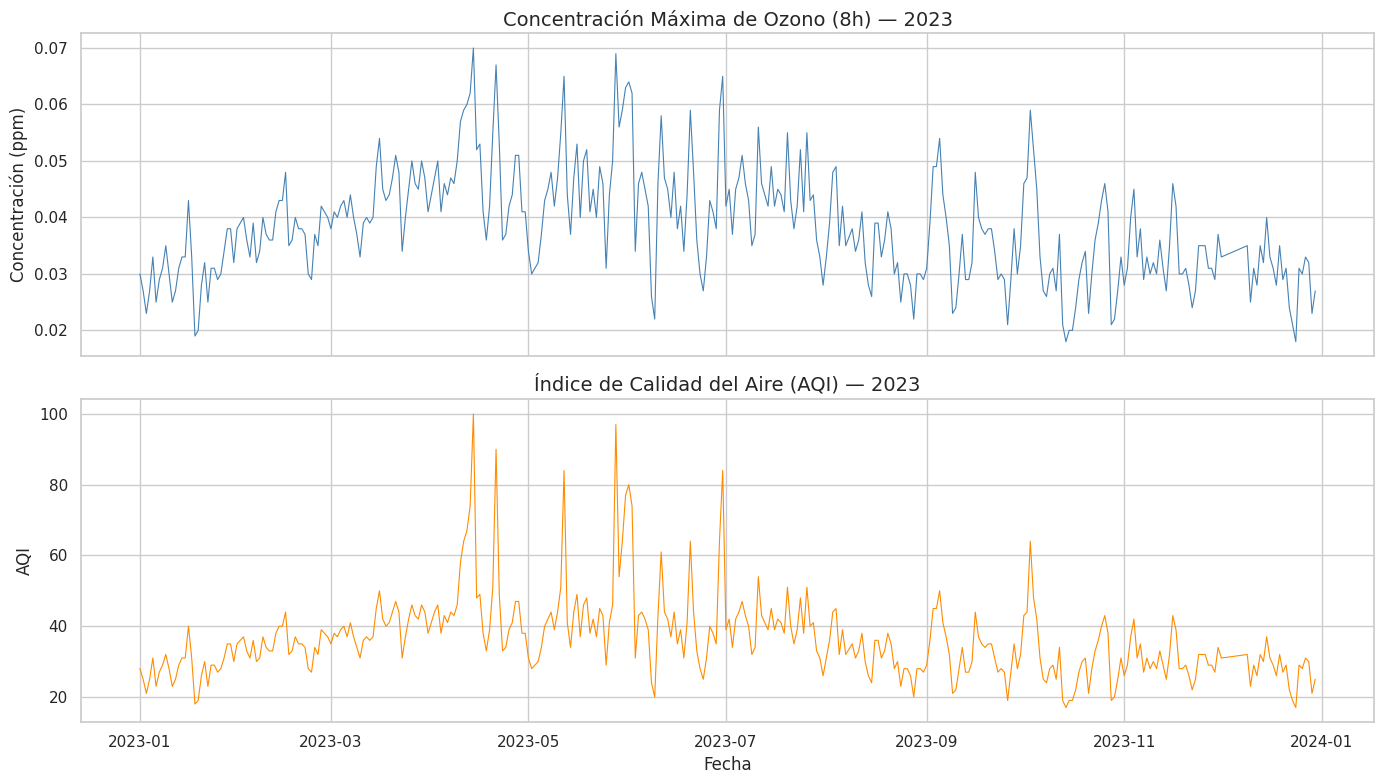

In [ ]:
# Evolución temporal de la concentración de Ozono y el AQI
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df['Date'], df['Daily Max 8-hour Ozone Concentration'],
             color='steelblue', linewidth=0.8)
axes[0].set_title('Concentración Máxima de Ozono (8h) — 2023', fontsize=14)
axes[0].set_ylabel('Concentración (ppm)')

axes[1].plot(df['Date'], df['Daily AQI Value'],
             color='darkorange', linewidth=0.8)
axes[1].set_title('Índice de Calidad del Aire (AQI) — 2023', fontsize=14)
axes[1].set_ylabel('AQI')
axes[1].set_xlabel('Fecha')

plt.tight_layout()
plt.show()

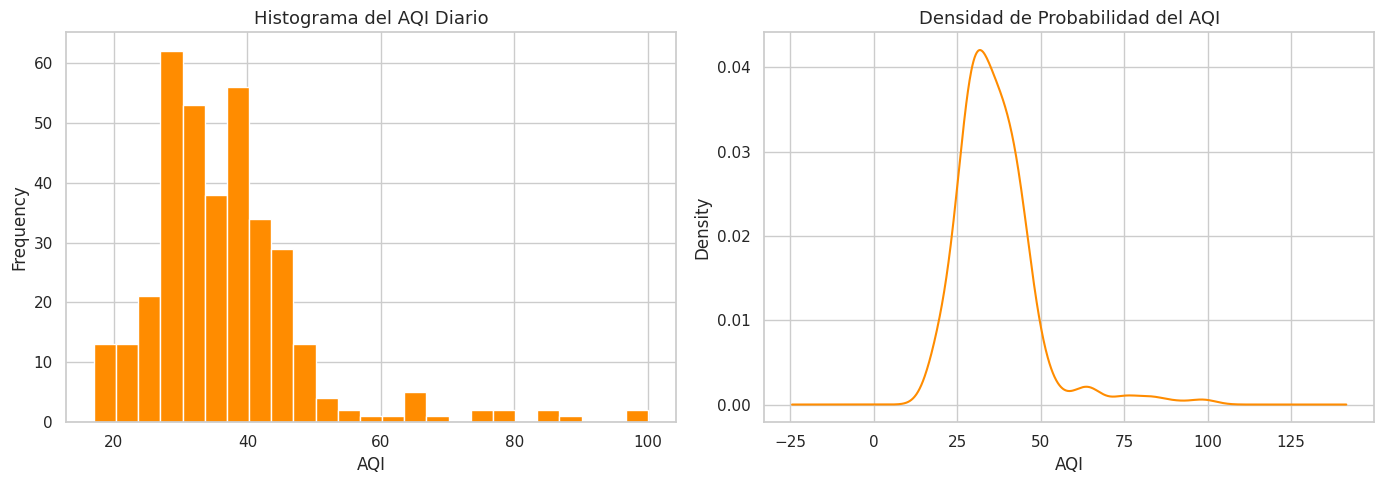

In [ ]:
# Distribución del AQI (variable objetivo)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Daily AQI Value'].plot.hist(bins=25, ax=axes[0], color='darkorange', edgecolor='white')
axes[0].set_title('Histograma del AQI Diario', fontsize=13)
axes[0].set_xlabel('AQI')

df['Daily AQI Value'].plot.density(ax=axes[1], color='darkorange')
axes[1].set_title('Densidad de Probabilidad del AQI', fontsize=13)
axes[1].set_xlabel('AQI')

plt.tight_layout()
plt.show()

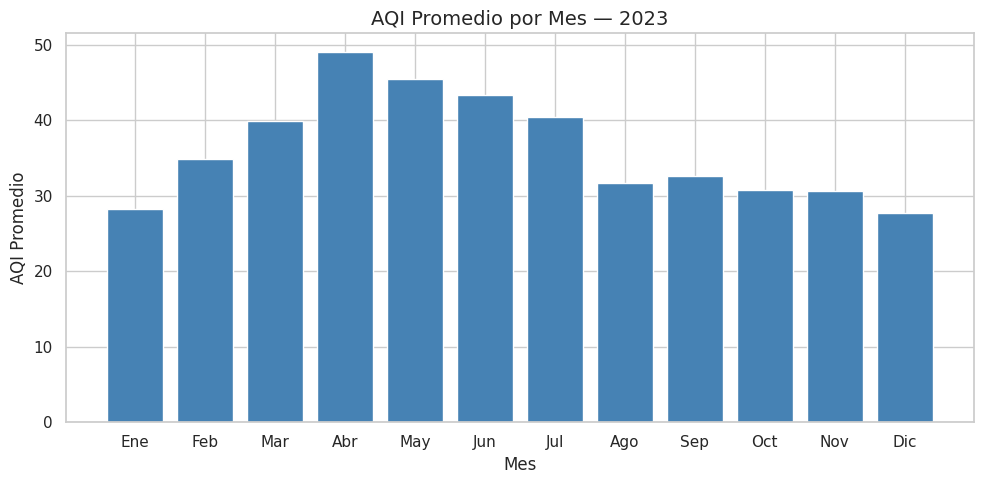

In [ ]:
# AQI promedio por mes (estacionalidad)
aqi_mes = df.groupby('Mes')['Daily AQI Value'].mean()
nombres_mes = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

plt.figure(figsize=(10, 5))
plt.bar(nombres_mes, aqi_mes.values, color='steelblue', edgecolor='white')
plt.title('AQI Promedio por Mes — 2023', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('AQI Promedio')
plt.tight_layout()
plt.show()

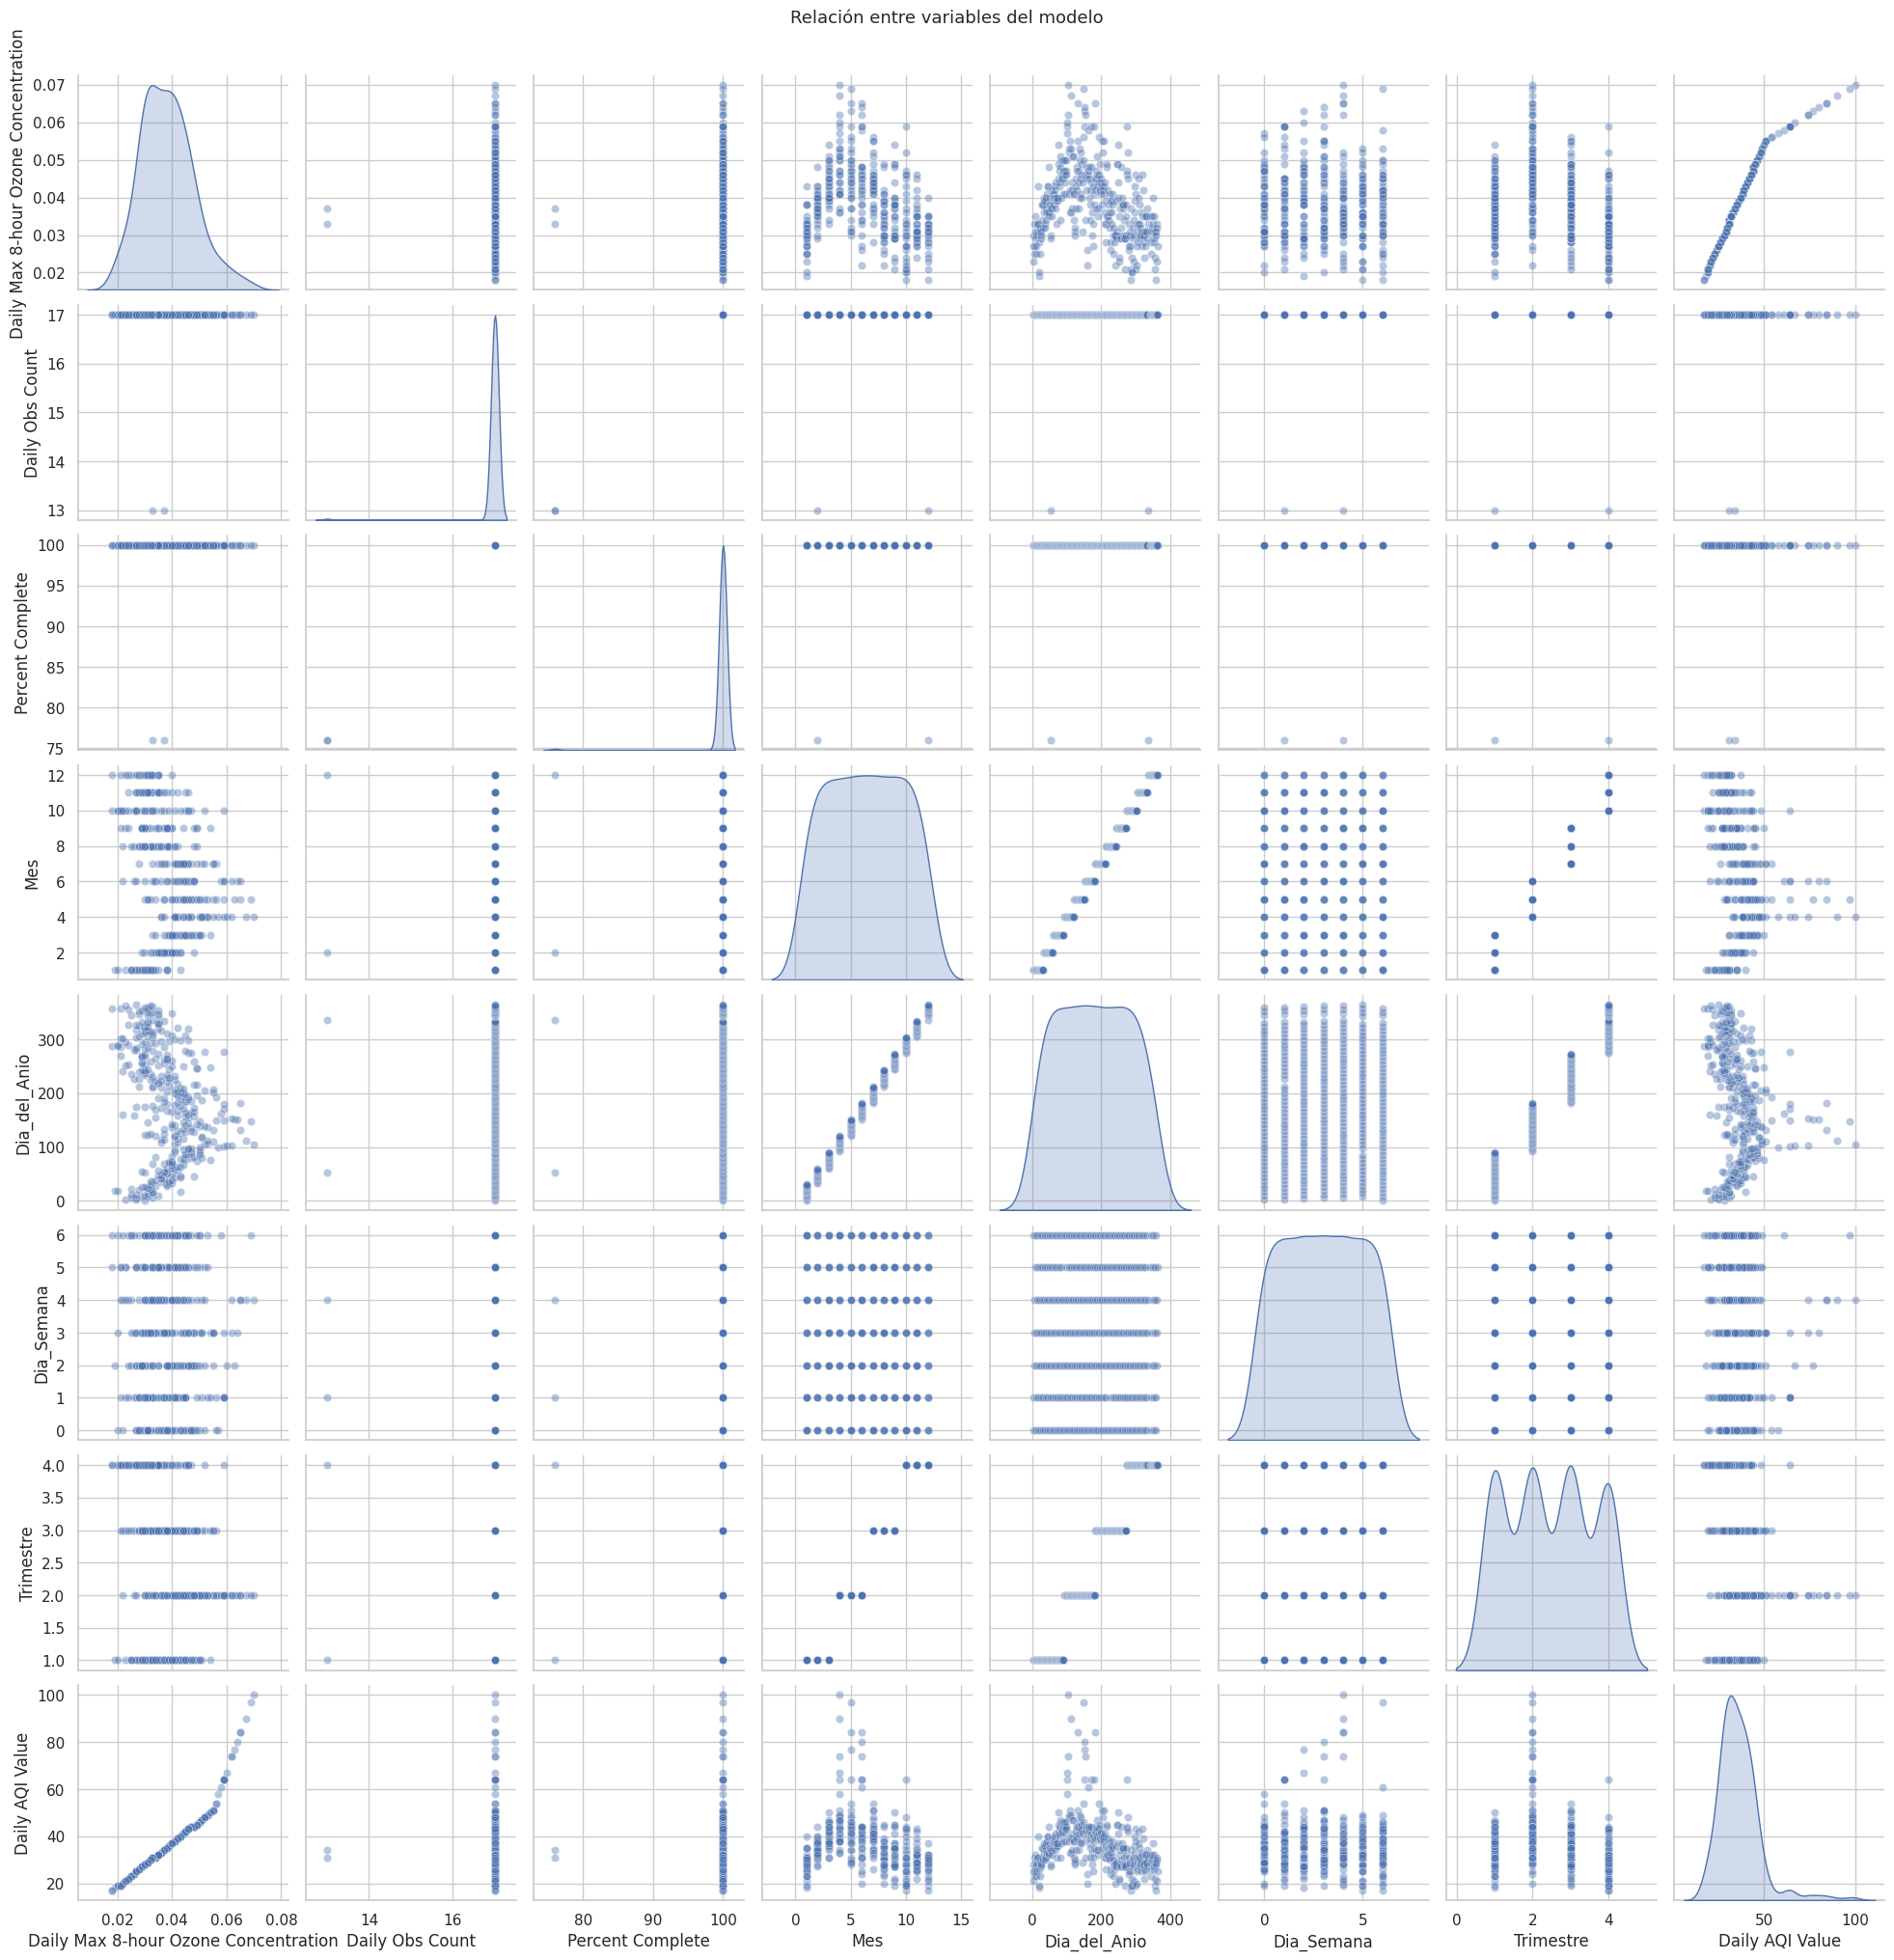

In [ ]:
# Pairplot de las variables seleccionadas
sns.pairplot(df_model, diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Relación entre variables del modelo', y=1.02, fontsize=13)
plt.show()

## 6. Matriz de Correlación y Mapa de Calor

In [ ]:
# Calculamos la matriz de correlación
corr_matrix = df_model.corr().round(4)
corr_matrix

,Daily Max 8-hour Ozone Concentration,Daily Obs Count,Percent Complete,Mes,Dia_del_Anio,Dia_Semana,Trimestre,Daily AQI Value
Daily Max 8-hour Ozone Concentration,1.0000,0.0259,0.0259,-0.2566,-0.2638,-0.0325,-0.2590,0.9542
Daily Obs Count,0.0259,1.0000,1.0000,-0.0132,-0.0101,0.0188,-0.0016,0.0248
Percent Complete,0.0259,1.0000,1.0000,-0.0132,-0.0101,0.0188,-0.0016,0.0248
Mes,-0.2566,-0.0132,-0.0132,1.0000,0.9965,0.0100,0.9708,-0.2235
Dia_del_Anio,-0.2638,-0.0101,-0.0101,0.9965,1.0000,0.0085,0.9674,-0.2283
Dia_Semana,-0.0325,0.0188,0.0188,0.0100,0.0085,1.0000,0.0076,-0.0116
Trimestre,-0.2590,-0.0016,-0.0016,0.9708,0.9674,0.0076,1.0000,-0.2235
Daily AQI Value,0.9542,0.0248,0.0248,-0.2235,-0.2283,-0.0116,-0.2235,1.0000


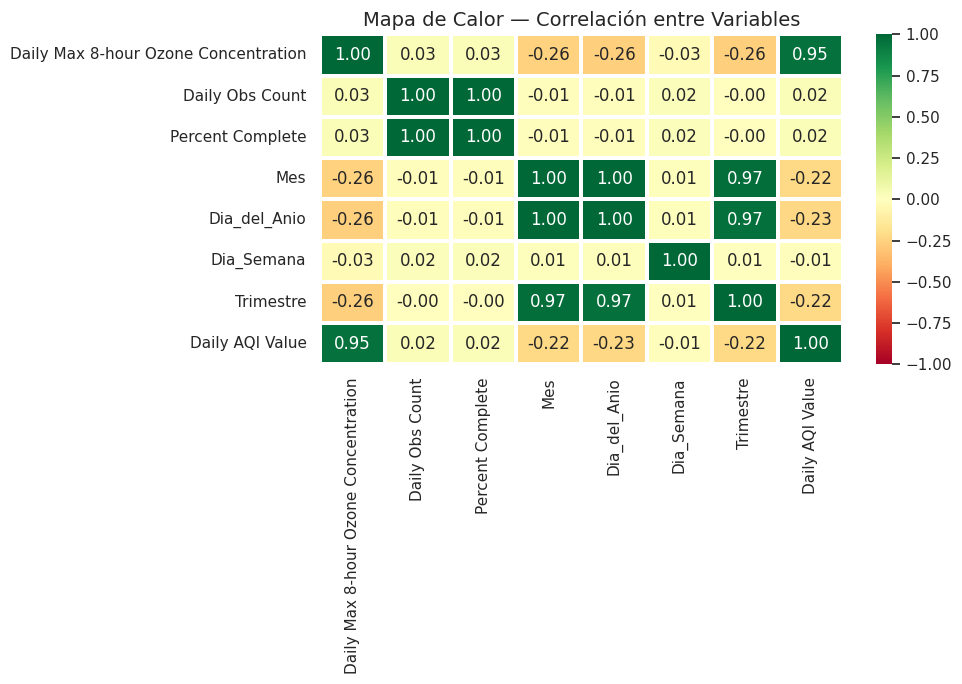

In [ ]:
# Mapa de calor
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    linewidths=1.5,
    cmap='RdYlGn',
    vmin=-1, vmax=1
)
plt.title('Mapa de Calor — Correlación entre Variables', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Definición de Variables para el Modelo

- **Variables de entrada (X):** todas las columnas excepto la variable objetivo.
- **Variable objetivo (Y):** `Daily AQI Value` — el índice de calidad del aire que queremos predecir.

In [ ]:
# Separar X e Y
l_column = list(df_model.columns)
len_feature = len(l_column)

X = df_model[l_column[0:len_feature - 1]]  # Variables predictoras
y = df_model[l_column[len_feature - 1]]    # Variable objetivo: Daily AQI Value

print("Variables de entrada (X):")
print(list(X.columns))
print("\nVariable objetivo (y):", y.name)
print("\nTamaño del dataset:", X.shape)

Variables de entrada (X):
['Daily Max 8-hour Ozone Concentration', 'Daily Obs Count', 'Percent Complete', 'Mes', 'Dia_del_Anio', 'Dia_Semana', 'Trimestre']

Variable objetivo (y): Daily AQI Value

Tamaño del dataset: (355, 7)


In [ ]:
X.head()

,Daily Max 8-hour Ozone Concentration,Daily Obs Count,Percent Complete,Mes,Dia_del_Anio,Dia_Semana,Trimestre
0,0.030,17,100.0,1,1,6,1
1,0.027,17,100.0,1,2,0,1
2,0.023,17,100.0,1,3,1,1
3,0.027,17,100.0,1,4,2,1
4,0.033,17,100.0,1,5,3,1


In [ ]:
y.head()

,Daily AQI Value
0,28
1,25
2,21
3,25
4,31


## 8. División Entrenamiento – Prueba

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba:        {X_test.shape[0]} muestras")

Entrenamiento: 248 muestras
Prueba:        107 muestras


## 9. Modelo de Regresión Lineal

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

lm = LinearRegression()
lm.fit(X_train, y_train)

print("Término de intersección (intercepto):", round(lm.intercept_, 4))

Término de intersección (intercepto): -7.0087


In [ ]:
# Coeficientes del modelo
cdf = pd.DataFrame(
    data=lm.coef_,
    index=X_train.columns,
    columns=['Coeficiente']
)
cdf

,Coeficiente
Daily Max 8-hour Ozone Concentration,1143.295216
Daily Obs Count,-0.001678
Percent Complete,-0.010069
Mes,-0.831754
Dia_del_Anio,0.026607
Dia_Semana,0.071402
Trimestre,0.310315


In [ ]:
# Cálculo del Error Estándar y Estadístico t para cada coeficiente
n = X_train.shape[0]
k = X_train.shape[1]
dfN = n - k

train_pred  = lm.predict(X_train)
train_error = np.square(train_pred - y_train)
sum_error   = np.sum(train_error)

se_list = []
for col in X_train.columns:
    r = (sum_error / dfN) / np.sum(np.square(X_train[col] - X_train[col].mean()))
    se_list.append(np.sqrt(r))

cdf['Error Estándar'] = se_list
cdf['t-estadístico']  = cdf['Coeficiente'] / cdf['Error Estándar']
cdf.round(4)

,Coeficiente,Error Estándar,t-estadístico
Daily Max 8-hour Ozone Concentration,1143.2952,22.7701,50.2103
Daily Obs Count,-0.0017,0.6193,-0.0027
Percent Complete,-0.0101,0.1032,-0.0976
Mes,-0.8318,0.0662,-12.5694
Dia_del_Anio,0.0266,0.0022,12.3503
Dia_Semana,0.0714,0.1096,0.6517
Trimestre,0.3103,0.2009,1.5449


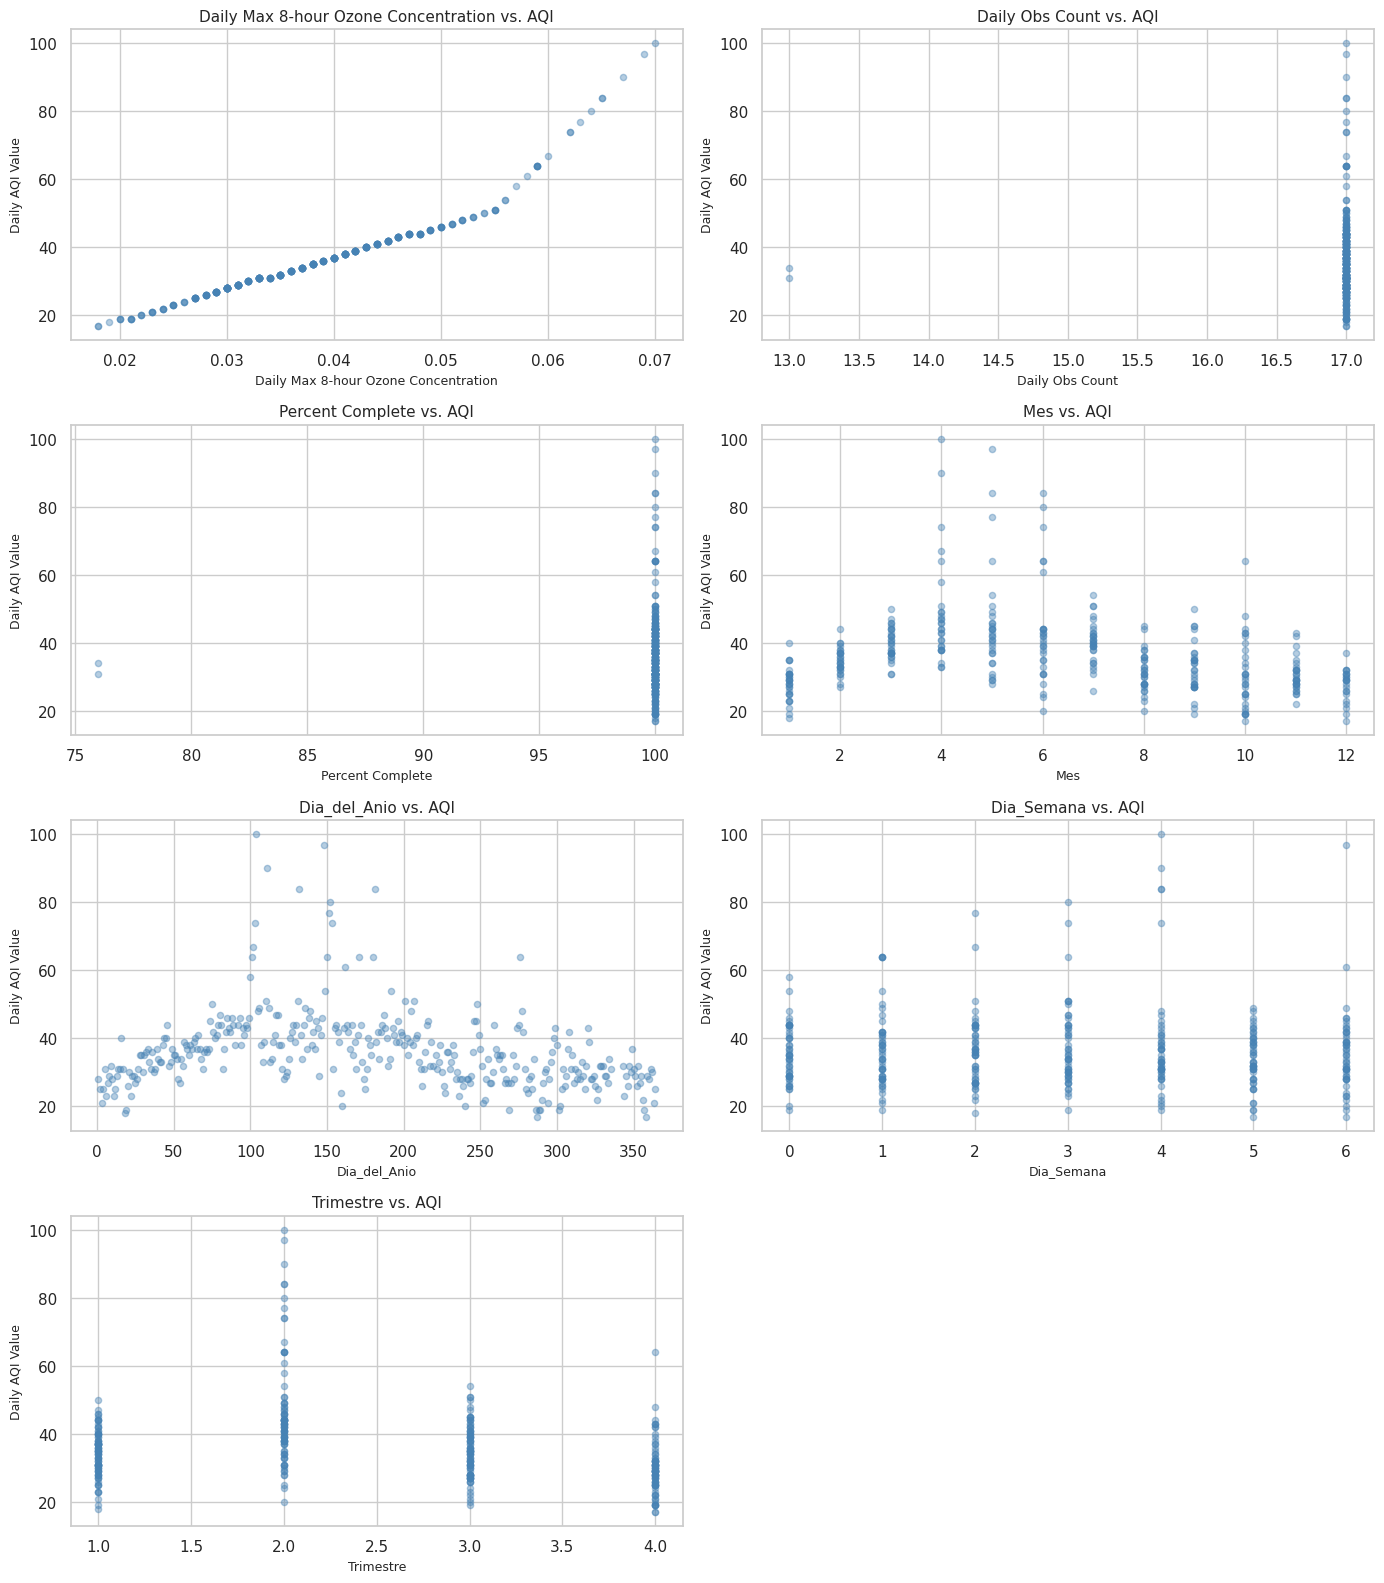

In [ ]:
# Gráfica: cada variable predictora vs. Daily AQI Value
from matplotlib import gridspec

features = list(X.columns)
n_feat   = len(features)
n_cols   = 2
n_rows   = (n_feat + 1) // n_cols

fig = plt.figure(figsize=(14, n_rows * 4))
gs  = gridspec.GridSpec(n_rows, n_cols)

for i, feat in enumerate(features):
    ax = plt.subplot(gs[i])
    ax.scatter(df_model[feat], df_model['Daily AQI Value'], alpha=0.4, color='steelblue', s=20)
    ax.set_title(f'{feat} vs. AQI', fontsize=11)
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('Daily AQI Value', fontsize=9)

plt.tight_layout()
plt.show()

## 10. Evaluación del Modelo de Regresión Lineal

In [ ]:
# Generamos predicciones sobre el conjunto de prueba
predictions = lm.predict(X_test)

print("Tipo del objeto predicho :", type(predictions))
print("Tamaño del objeto predicho:", predictions.shape)

Tipo del objeto predicho : <class 'numpy.ndarray'>
Tamaño del objeto predicho: (107,)


In [ ]:
# Métricas de evaluación
mae  = metrics.mean_absolute_error(y_test, predictions)
mse  = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2   = metrics.r2_score(y_test, predictions)

print(f"MAE  (Error Absoluto Medio):         {mae:.4f}")
print(f"MSE  (Error Cuadrático Medio):       {mse:.4f}")
print(f"RMSE (Raíz del Error Cuadrático):    {rmse:.4f}")
print(f"R²   (Coeficiente de determinación): {r2:.4f}")

MAE  (Error Absoluto Medio):         1.8091
MSE  (Error Cuadrático Medio):       12.6040
RMSE (Raíz del Error Cuadrático):    3.5502
R²   (Coeficiente de determinación): 0.9128


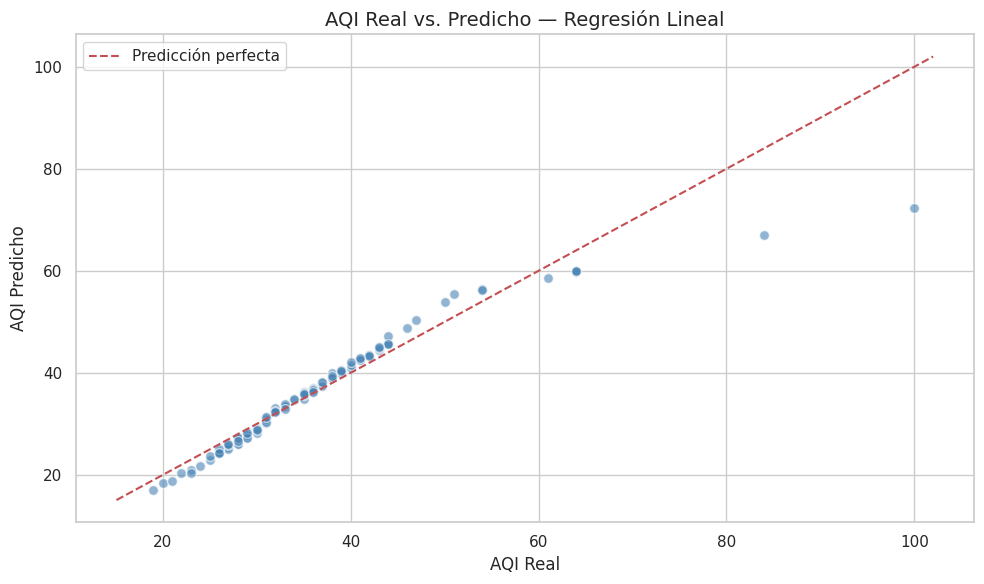

In [ ]:
# Diagrama de dispersión: AQI real vs. predicho
plt.figure(figsize=(10, 6))
plt.title('AQI Real vs. Predicho — Regresión Lineal', fontsize=14)
plt.xlabel('AQI Real', fontsize=12)
plt.ylabel('AQI Predicho', fontsize=12)
plt.scatter(x=y_test, y=predictions, alpha=0.6, color='steelblue', edgecolors='white', s=50)

# Línea de referencia perfecta
lims = [min(y_test.min(), predictions.min()) - 2, max(y_test.max(), predictions.max()) + 2]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Análisis de Residuos

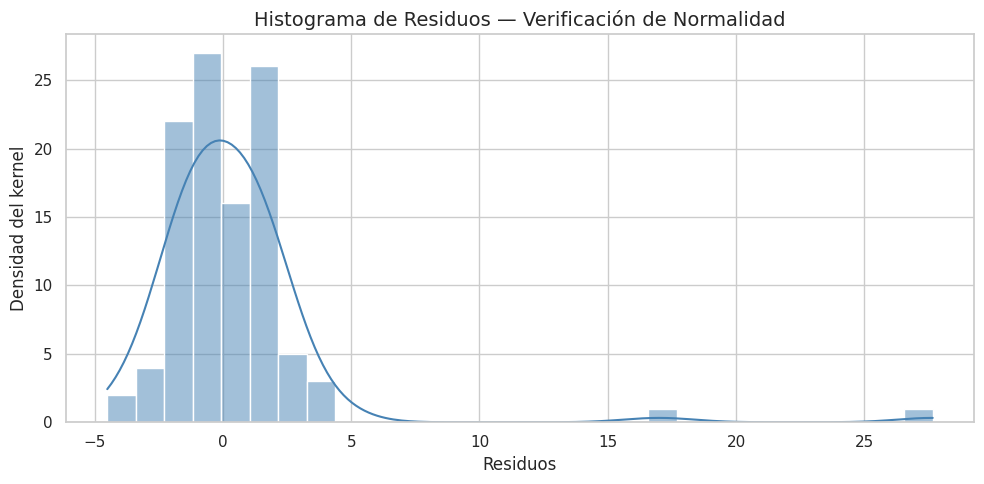

In [ ]:
residuos = y_test - predictions

# Histograma y densidad de los residuos
plt.figure(figsize=(10, 5))
plt.title('Histograma de Residuos — Verificación de Normalidad', fontsize=14)
plt.xlabel('Residuos', fontsize=12)
plt.ylabel('Densidad del kernel', fontsize=12)
sns.histplot(residuos, kde=True, color='steelblue', edgecolor='white')
plt.tight_layout()
plt.show()

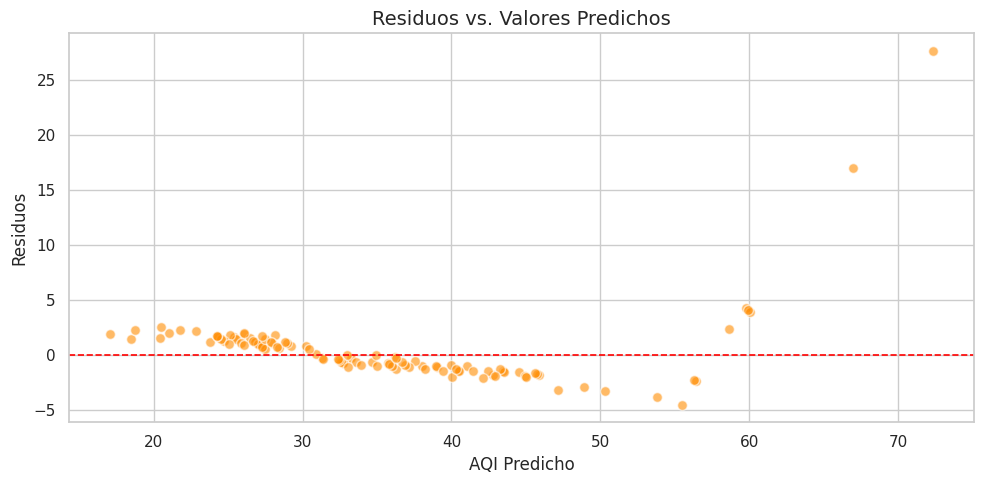

In [ ]:
# Gráfica de residuos vs. valores predichos (homocedasticidad)
plt.figure(figsize=(10, 5))
plt.title('Residuos vs. Valores Predichos', fontsize=14)
plt.xlabel('AQI Predicho', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.scatter(x=predictions, y=residuos, alpha=0.6, color='darkorange', edgecolors='white', s=50)
plt.axhline(0, color='red', linestyle='--', linewidth=1.2)
plt.tight_layout()
plt.show()

## 12. Modelo de Árbol de Decisión (Comparación)

In [ ]:
from sklearn import tree

# Creación y entrenamiento del árbol de decisión
tree_model = tree.DecisionTreeRegressor(max_depth=5, random_state=10)
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=10)

In [ ]:
# Predicciones del árbol de decisión
tree_pred = tree_model.predict(X_test)

mae_t  = metrics.mean_absolute_error(y_test, tree_pred)
mse_t  = metrics.mean_squared_error(y_test, tree_pred)
rmse_t = np.sqrt(mse_t)
r2_t   = metrics.r2_score(y_test, tree_pred)

print("=== Árbol de Decisión ===")
print(f"MAE:  {mae_t:.4f}")
print(f"MSE:  {mse_t:.4f}")
print(f"RMSE: {rmse_t:.4f}")
print(f"R²:   {r2_t:.4f}")

=== Árbol de Decisión ===
MAE:  0.6847
MSE:  1.6609
RMSE: 1.2888
R²:   0.9885


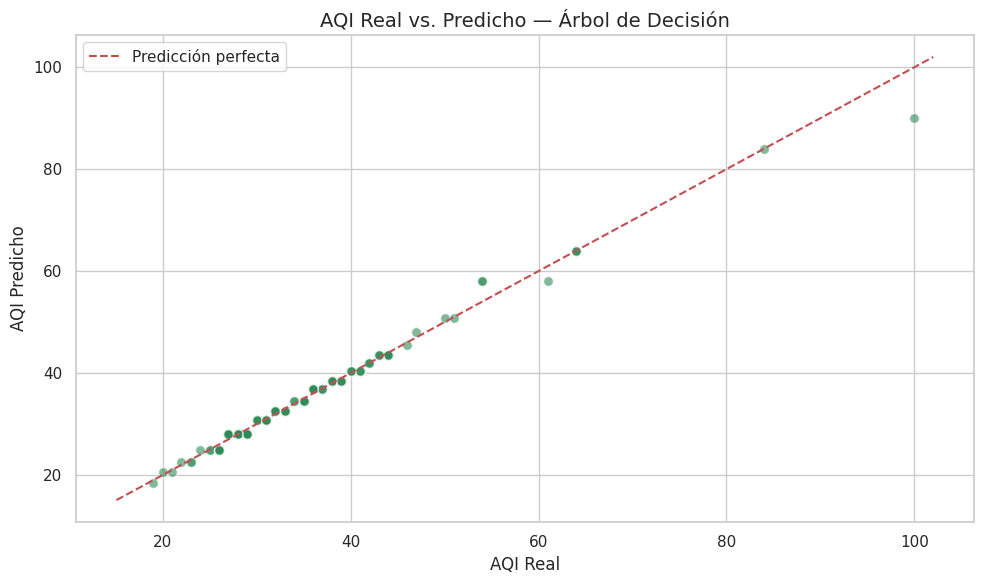

In [ ]:
# Comparación: AQI real vs. predicho (Árbol de Decisión)
plt.figure(figsize=(10, 6))
plt.title('AQI Real vs. Predicho — Árbol de Decisión', fontsize=14)
plt.xlabel('AQI Real', fontsize=12)
plt.ylabel('AQI Predicho', fontsize=12)
plt.scatter(x=y_test, y=tree_pred, alpha=0.6, color='seagreen', edgecolors='white', s=50)
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
plt.legend()
plt.tight_layout()
plt.show()

Importancia relativa de las características:
  Daily Max 8-hour Ozone Concentration: 0.9993
  Dia_del_Anio: 0.0007
  Daily Obs Count: 0.0000
  Percent Complete: 0.0000
  Mes: 0.0000
  Dia_Semana: 0.0000
  Trimestre: 0.0000


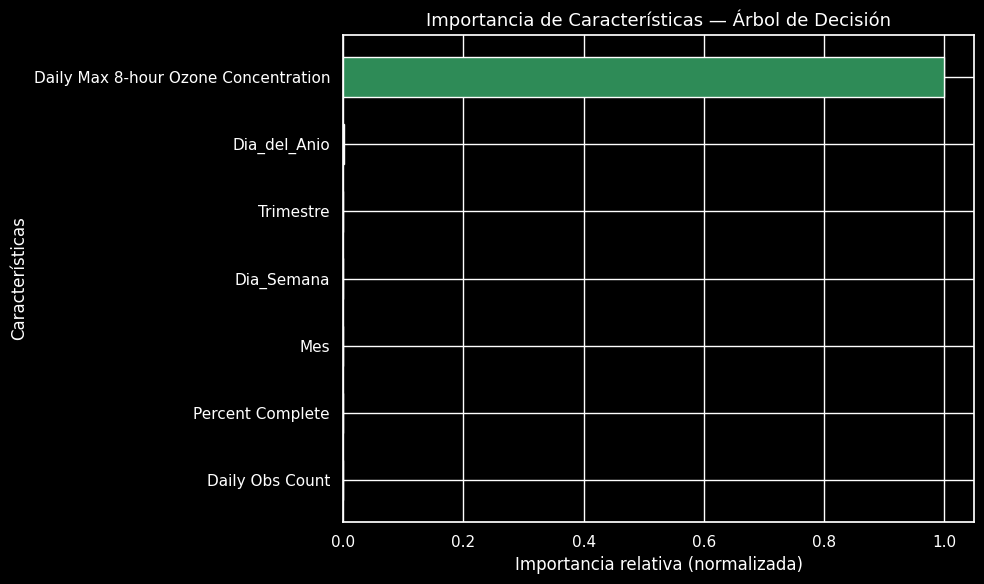

In [ ]:
# Importancia relativa de las características (Árbol de Decisión)
importancias = tree_model.feature_importances_
feat_names   = list(X.columns)
n_feat_      = len(feat_names)

print("Importancia relativa de las características:")
for f, imp in sorted(zip(feat_names, importancias), key=lambda x: x[1], reverse=True):
    print(f"  {f}: {imp:.4f}")

with plt.style.context('dark_background'):
    indices_ord = np.argsort(importancias)
    plt.figure(figsize=(10, 6))
    plt.grid(True)
    plt.barh(
        [feat_names[i] for i in indices_ord],
        importancias[indices_ord],
        height=0.6,
        color='seagreen'
    )
    plt.xlabel('Importancia relativa (normalizada)', fontsize=12)
    plt.ylabel('Características', fontsize=12)
    plt.title('Importancia de Características — Árbol de Decisión', fontsize=13)
    plt.tight_layout()
    plt.show()

## 13. Comparación Final de Modelos

In [ ]:
resumen = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Árbol de Decisión'],
    'MAE':    [round(mae, 4), round(mae_t, 4)],
    'MSE':    [round(mse, 4), round(mse_t, 4)],
    'RMSE':   [round(rmse, 4), round(rmse_t, 4)],
    'R²':     [round(r2, 4), round(r2_t, 4)]
})
resumen.set_index('Modelo', inplace=True)
resumen

,MAE,MSE,RMSE,R²
Modelo,,,,
Regresión Lineal,1.8091,12.6040,3.5502,0.9128
Árbol de Decisión,0.6847,1.6609,1.2888,0.9885


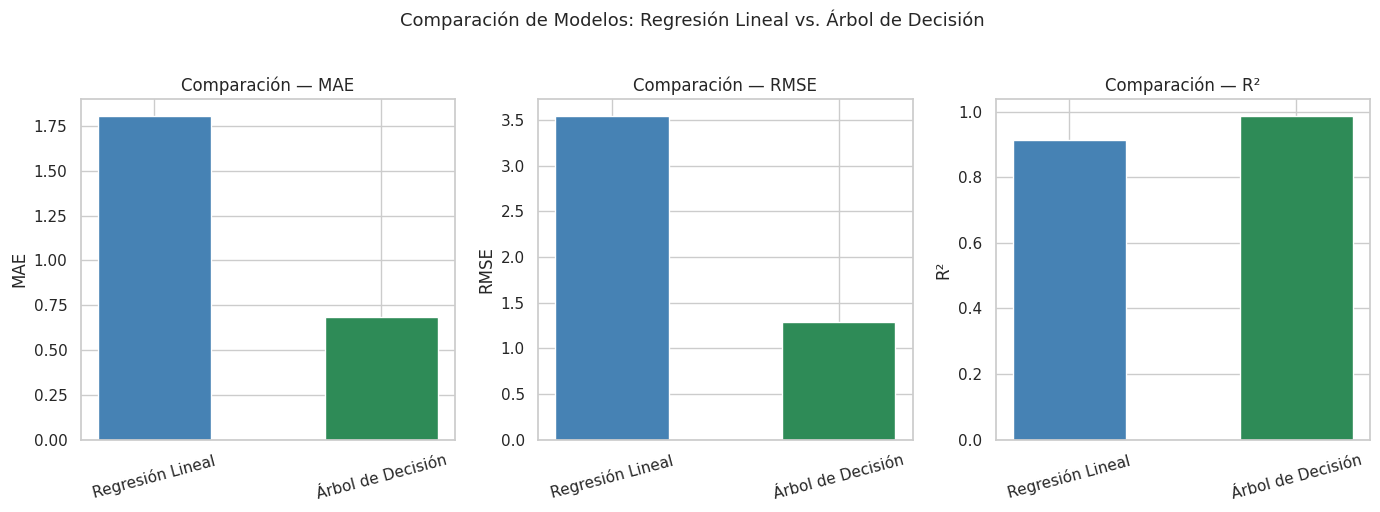

In [ ]:
# Visualización comparativa de R²
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, metric in enumerate(['MAE', 'RMSE', 'R²']):
    axes[i].bar(resumen.index, resumen[metric],
                color=['steelblue', 'seagreen'], edgecolor='white', width=0.5)
    axes[i].set_title(f'Comparación — {metric}', fontsize=12)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Comparación de Modelos: Regresión Lineal vs. Árbol de Decisión', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 14. Análisis detallado con Statsmodels (OLS Summary)

In [ ]:
import statsmodels.api as sm

# Añadimos la constante a las variables de entrada (X)
Xs = sm.add_constant(X)

# Ajustamos el modelo de Regresión Lineal por Mínimos Cuadrados Ordinarios (OLS)
stat_model = sm.OLS(y, Xs)
stat_result = stat_model.fit()

# Mostramos el resumen completo del modelo
print(stat_result.summary())

                            OLS Regression Results                            
Dep. Variable:        Daily AQI Value   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                     603.2
Date:                Thu, 17 Sep 2026   Prob (F-statistic):          1.59e-180
Time:                        21:07:18   Log-Likelihood:                -944.87
No. Observations:                 355   AIC:                             1904.
Df Residuals:                     348   BIC:                             1931.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


/tmp/ipykernel_937/1133071462.py:8: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  stat_result = stat_model.fit()


## 15. Conclusiones

En este taller aplicamos dos modelos de regresión para predecir el **Índice de Calidad del Aire (AQI)** diario en la estación Connecticut Hill, Nueva York, durante el año 2023.

**Variables utilizadas:**
- `Daily Max 8-hour Ozone Concentration` — concentración máxima de O₃ en 8 horas
- `Daily Obs Count` y `Percent Complete` — calidad del monitoreo
- Variables temporales derivadas: Mes, Día del año, Día de la semana, Trimestre

**Resultados:**
- La **Regresión Lineal** ofrece un modelo interpretable donde la concentración de ozono es el predictor más fuerte del AQI, lo cual tiene sentido físico dado que el AQI en este dataset se calcula directamente a partir de O₃.
- El **Árbol de Decisión** captura relaciones no lineales y puede ofrecer mejor ajuste, a costa de mayor complejidad.
- Las variables temporales (especialmente el mes) reflejan la **estacionalidad** del ozono, que tiende a ser mayor en los meses cálidos (verano).

> **Nota:** Un R² cercano a 1.0 indica que la concentración de ozono es prácticamente suficiente para determinar el AQI, dado que en este dataset el AQI se calcula directamente de la concentración medida.